In [1]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import corner
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import BaryonForge as bfg
import pyccl as ccl
from scipy.integrate import cumulative_trapezoid, simpson
from astropy import constants as con
import os
from scipy.stats import gaussian_kde
import h5py

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=2.1)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

os.environ["PK_MODEL"] = "BCEmu7_high_z"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
os.environ["DIR_PATH"] = "data/frb_results"
os.environ["SAMPLE"] = "frb_sample"
os.environ["SAMPLE_EXTENDED"] = "Yes"
from mcmc_funcs import *
from astropy.cosmology import Planck18 as cosmo
import matplotlib.cm as cm
from matplotlib.colors import Normalize

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 2   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5



Not using emulators.
Unknown Pk_model!


In [2]:
from scipy.stats import lognorm
from scipy.signal import fftconvolve
import matplotlib.cm as cm
from matplotlib.colors import Normalize

G = con.G.cgs.value
m_p = con.m_p.cgs.value
c = con.c.cgs.value
pc = con.pc.cgs.value; Mpc = 1e6*pc
chi_e = 1 - (0.2453 / 2)

k_fields = np.geomspace(1e-4, 1e2, 1000)
z_bins = np.linspace(0, 2, 1000)

def normalized_lognorm_pdf(x, mu, sigma):
    pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    return pdf / np.trapz(pdf, x)


def compute_extragal_pdfs(redshifts, mu_cosmic, sigma_cosmic,
                          mu_host_rest, sigma_host_rest, DM_grid):
    pdf_list = []

    for z, mu_c, sig_c in zip(redshifts, mu_cosmic, sigma_cosmic):

        # Cosmic DM term
        pdf_cosmic = normalized_lognorm_pdf(DM_grid, mu_c, sig_c)

        # Host DM in observer frame
        DM_host_obs = DM_grid / (1 + z)
        pdf_host_rest = lognorm.pdf(DM_host_obs, s=sigma_host_rest, scale=np.exp(mu_host_rest))

        # Jacobian
        pdf_host_obs = (1 + z) * pdf_host_rest
        pdf_host_obs /= np.trapz(pdf_host_obs, DM_grid)

        # Convolution
        pdf = fftconvolve(pdf_cosmic, pdf_host_obs, mode="full")[:len(DM_grid)]
        pdf /= np.trapz(pdf, DM_grid)

        pdf_list.append(pdf)

    pdf_arr = np.array(pdf_list)
    pdf_arr = np.clip(pdf_arr, 1e-50, None)
    return pdf_arr

100%|█████████████████████████████████████████████████████████████████| 10/10 [06:03<00:00, 36.34s/it]


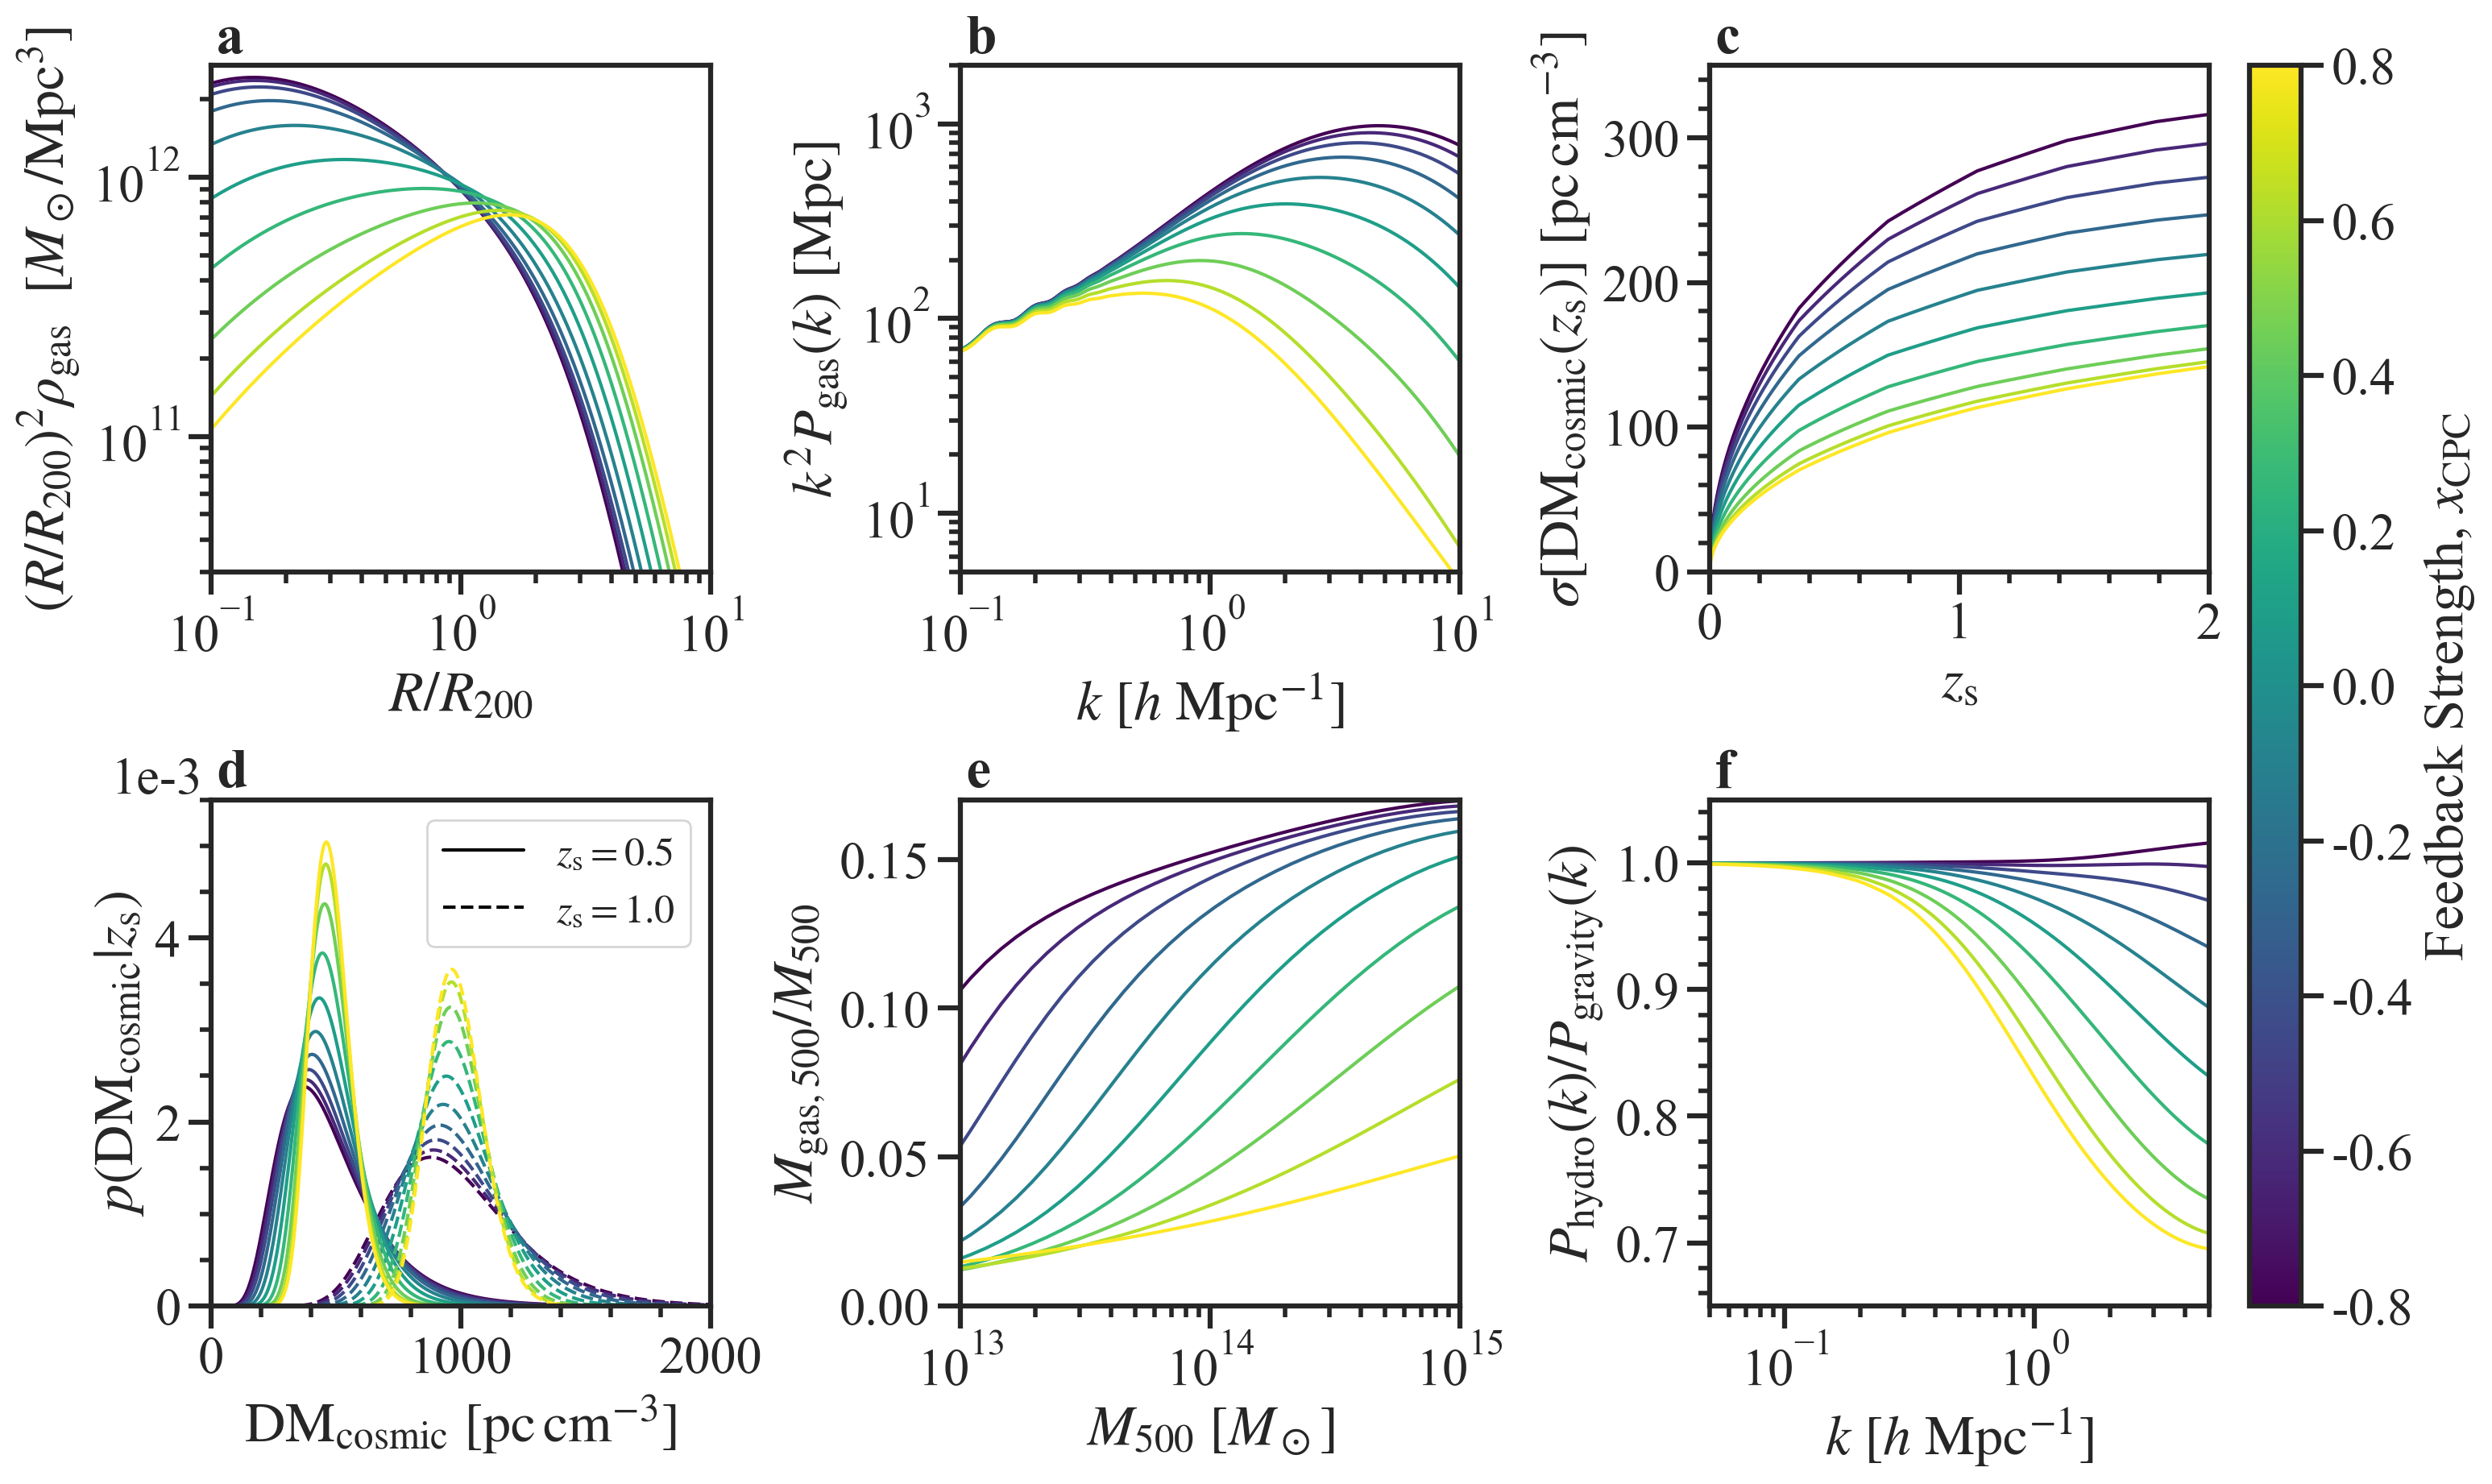

In [3]:
import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 2.25   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2.25
mpl.rcParams['ytick.major.width'] = 2.25
mpl.rcParams['xtick.minor.width'] = 2
mpl.rcParams['ytick.minor.width'] = 2

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5

cosmo_ccl = ccl.Cosmology(Omega_c = cosmo.Om0-cosmo.Ob0, 
                      Omega_b = cosmo.Ob0, 
                      h = cosmo.H0.value/100, 
                      sigma8 = 0.8111, 
                      n_s = 0.9665, 
                      matter_power_spectrum='linear'
                     )
fb = cosmo_ccl.cosmo.params.Omega_b / cosmo_ccl.cosmo.params.Omega_m # Cosmic baryon fraction

def compute_mass_fraction(Profile, Mass, a = 1, Rfac = 1):
    mdef  = ccl.halos.massdef.MassDef500c
    R500c = mdef.get_radius(cosmo_ccl, Mass, a) / a
    out   = np.zeros_like(Mass) + -99
    for i in range(Mass.size):        
        r = np.geomspace(R500c[i] * 1e-8, R500c[i] * Rfac, 1000)
        m = np.trapz(4 * np.pi * r**2 * Profile.real(cosmo_ccl, r, Mass[i], a), x = r) #Cumulative mass fraction
        out[i] = m/Mass[i] 
    return out

c_M_relation = ccl.halos.concentration.ConcentrationIshiyama21


fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=False)
plt.subplots_adjust(wspace=0.4)
cmap = cm.viridis; norm = Normalize(vmin=-0.8, vmax=0.8)

ax0, ax1, ax2, ax3, ax5, ax4 = axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1], axes[1,2]
# CPC-1
p0 = np.array([13.05, 4.68, 0.97, 7.28])
v  = np.array([1.00, 0.41, -0.93, -0.35])
t_vals = np.linspace(-0.8, .8, 10)
params = p0 + np.outer(t_vals, v)

# columns: logMc, theta_ej, mu_beta, delta

for i in tqdm(range(len(params))):
    log_Mc = params[i, 0]
    feedback_params = {"log_Mc": params[i, 0], "theta_ej": params[i, 1], "eta_delta": 0.2, "delta": params[i, 3], 
                       "mu_beta": params[i, 2], "gamma": 2.5, "eta": 0.2, "A": 0.055/2, "tau": -1.5}
    
    P_gas = Pgas_BCEmu(cosmo.H0.cgs.value, cosmo.Ob0, cosmo.Om0, 0.8111, feedback_params, np.array([0]))[1][0]
    
    ax1.loglog(k_fields/(cosmo.H0.value/100), (k_fields**2) * P_gas, color=cmap(norm(t_vals[i])))
    
    DM_var = get_DM_variance(np.array([cosmo.H0.cgs.value]), np.array([cosmo.Ob0]), 
                             np.array([cosmo.Om0]), np.array([0.8111]), 
                             np.array([feedback_params]), 
                             z_bins, "BCEmu")[0]
    ax2.plot(z_bins, DM_var, color=cmap(norm(t_vals[i])))
    
    DM_mean = DM_cosmic_mean(np.array([cosmo.Om0]), np.array([cosmo.Ob0]), 
                             np.array([cosmo.H0.cgs.value]), np.array([0.8111]), 
                             np.array([feedback_params]), 
                             "BCEmu", z_bins)[0]
    mu_cosmic = np.log(DM_mean**2 / np.sqrt(DM_mean**2 + DM_var**2))
    sigma_cosmic = np.sqrt(np.log(1 + DM_var**2 / DM_mean**2))

    DM_grid = np.linspace(0, 10000, 10000)
    pdf_DMcosmic = compute_extragal_pdfs(
        z_bins,
        mu_cosmic, sigma_cosmic,
        1, 1,
        DM_grid
    )
    ax3.plot(DM_grid, pdf_DMcosmic[250, :], color=cmap(norm(t_vals[i])))
    ax3.plot(DM_grid, pdf_DMcosmic[500, :], color=cmap(norm(t_vals[i])), ls="--")
    
    SPk = SPk_BCEmu(cosmo.H0.cgs.value, cosmo.Ob0, cosmo.Om0, 0.8111, feedback_params)
    ax4.plot(k_fields/(cosmo.H0.value/100), SPk, color=cmap(norm(t_vals[i])))
    ax4.set(xlim = [5e-2, 5], ylim=[0.65, 1.05], xscale='log', 
            xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$',
            ylabel=r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')
    
    M500c = np.geomspace(1e12, 1e15, 50)

    par = dict(theta_ej = params[i, 1], theta_co = 0.1, M_c = (10**params[i, 0])/cosmo_ccl.cosmo.params.h, 
               mu_beta = params[i, 2], eta = 0.2, eta_delta = 0.2, tau = -1.5, tau_delta = 0, A = 0.055/2, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = params[i, 3])
    GAS = bfg.Profiles.Schneider19.Gas(**par, mass_def = ccl.halos.massdef.MassDef500c, c_M_relation=c_M_relation)
    STR = bfg.Profiles.Schneider19.Stars(**par, mass_def = ccl.halos.massdef.MassDef500c, c_M_relation=c_M_relation)
    ax5.plot(M500c, compute_mass_fraction(GAS, M500c), color=cmap(norm(t_vals[i])))
    
    mdef  = ccl.halos.massdef.MassDef200c
    R200c = mdef.get_radius(cosmo_ccl, 1e14, 1)
    R = np.geomspace(0.1, 10, 1000)
    x = R/R200c
    ax0.plot(x, x**2 * (GAS.real(cosmo_ccl, R, np.array([1e14]), 1)[0]), color=cmap(norm(t_vals[i])))
    
    
ax0.set_xlabel(r'$R/R_{\rm 200}$')
ax0.set_xscale('log'); ax0.set_yscale('log')
ax0.set_xlim(0.1, 10); ax0.set_ylim(3e10, 2.7e12)
ax0.set_ylabel(r'$(R/R_{\rm 200})^2\rho_\mathrm{gas}$  $[M_\odot/{\rm Mpc}^3]$')


ax5.set_xlim(1e13, 1e15)
ax5.set_ylim(0, 0.17)
ax5.set_xscale('log')
ax5.set_ylabel(r'$M_\mathrm{gas,500}/M_\mathrm{500}$')
ax5.set_xlabel(r'$M_{500}~[M_\odot]$')


ax1.set_ylim(5, 2e3)
ax1.set_xlim(1e-1, 10)
ax1.set_xlabel(xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
ax1.set_ylabel(r'$k^2P_\mathrm{gas}(k)~[\mathrm{Mpc}]$')

ax2.set_ylim(0, 350)
ax2.set_xlim(0, 2)
ax2.set_xlabel(r'$z_\mathrm{s}$')
ax2.set_ylabel(r'$\sigma[\mathrm{DM}_\mathrm{cosmic}(z_\mathrm{s})]~[\mathrm{pc}\,\mathrm{cm}^{-3}]$')

ax3.set_xlim(0, 2000)
ax3.set_ylim(0, 5.5e-3)
ax3.set_xlabel(r'$\mathrm{DM}_\mathrm{cosmic}~[\mathrm{pc}\,\mathrm{cm}^{-3}]$')
ax3.set_ylabel(r'$p(\mathrm{DM}_\mathrm{cosmic}|z_\mathrm{s})$')
ax3.plot([], [], ls="-", label=r"$z_\mathrm{s}=0.5$", color="black")
ax3.plot([], [], ls="--", label=r"$z_\mathrm{s}=1.0$", color="black")
ax3.legend(fontsize=18)

sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
box = ax4.get_position()
ax4.set_position([box.x0*1.0, box.y0, box.width, box.height])
cbar_ax = plt.axes([box.x0*1.005 + box.width * 1.06, box.y0, 0.02, box.height*2.2])
cbar = fig.colorbar(sm, cax=cbar_ax, label=r"Feedback Strength, $x_\mathrm{CPC}$")

ax0.text(0.01, 1.05, "a", ha='left', va='center', weight='bold', transform=ax0.transAxes)
ax1.text(0.01, 1.05, "b", ha='left', va='center', weight='bold', transform=ax1.transAxes)
ax2.text(0.01, 1.05, "c", ha='left', va='center', weight='bold', transform=ax2.transAxes)
ax3.text(0.01, 1.05, "d", ha='left', va='center', weight='bold', transform=ax3.transAxes)
ax5.text(0.01, 1.05, "e", ha='left', va='center', weight='bold', transform=ax5.transAxes)
ax4.text(0.01, 1.05, "f", ha='left', va='center', weight='bold', transform=ax4.transAxes)


offset = ax3.yaxis.get_offset_text()
offset.set_x(-0.2)
offset.set_y(1.0)

ax2.yaxis.set_major_locator(plt.MultipleLocator(100))
ax2.yaxis.set_minor_locator(plt.MultipleLocator(20))
ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.2))

ax3.yaxis.set_major_locator(plt.MultipleLocator(2e-3))
ax3.yaxis.set_minor_locator(plt.MultipleLocator(5e-4))
ax3.xaxis.set_major_locator(plt.MultipleLocator(1000))
ax3.xaxis.set_minor_locator(plt.MultipleLocator(200))

ax4.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax4.yaxis.set_minor_locator(plt.MultipleLocator(0.02))

ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.subplots_adjust(wspace=0.5, hspace=0.45)

plt.savefig('figures/CPC1_variations.pdf', dpi=400, bbox_inches='tight')
